# Time-Shifted Dynamic Factor Model: Predicted vs Actual

Leave-one-out cross-sectional prediction using lagged factor structure.
For each node j at time t: estimate factors from t-lag, infer factor realisations
from the *other* N-1 nodes' current changes, predict node j.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from curve_pipeline import (
    build_deadline_market_universe,
    build_history_panel,
    _logit,
    _sigmoid,
)


In [38]:
MAX_EVENTS = 1200
MAX_MARKETS = 400
LOOKBACK_DAYS = 30
INTERVAL = "1h"
FIDELITY = 1

N_FACTORS = 2
LOOKBACK_BARS = 360
FACTOR_LAG = 30             # bars lag for factor estimation (30 * 1 min = 30 min)
EXCLUDE_EVENT_ID = "114242"


In [39]:
universe_df = build_deadline_market_universe(
    max_events=MAX_EVENTS,
    min_distinct_dates=2,
    include_closed=False,
)
universe_df = universe_df[universe_df["event_id"] != EXCLUDE_EVENT_ID].copy()

print(f"Universe (excl. Iran): {len(universe_df)} markets across {universe_df['event_id'].nunique()} events")

panel_df = build_history_panel(
    universe=universe_df,
    lookback_days=LOOKBACK_DAYS,
    interval=INTERVAL,
    fidelity=FIDELITY,
    max_markets=MAX_MARKETS,
    sleep_seconds=0.05,
)

print(f"Panel: {len(panel_df):,} rows, {panel_df['event_id'].nunique()} events")


Universe (excl. Iran): 485 markets across 135 events
Panel: 888,350 rows, 109 events


## Time-shifted leave-one-out factor model

For each event at each bar t:
1. Estimate factor loadings **B** and drift **mu** from the lookback window ending at `t - FACTOR_LAG`.
2. For each node j, exclude node j from the current change vector `dy[t]`.
3. Estimate factor realisations **f** from the remaining N-1 nodes using the stale **B**.
4. Predict node j: `predicted = mu[j] + B[j,:] @ f`.
5. Convert back to probability space.

Out-of-sample in time (stale factors) and cross-sectionally (leave-one-out).


In [40]:
def ts_dynamic_loo(panel, n_factors=2, lookback_bars=72, factor_lag=6):
    """Time-shifted leave-one-out dynamic factor prediction."""
    all_rows = []
    min_start = lookback_bars + factor_lag

    for event_id, edf in panel.groupby("event_id", dropna=False):
        question = edf["question"].iloc[0]
        wide = edf.pivot_table(
            index="timestamp", columns="deadline_date",
            values="probability_yes", aggfunc="last",
        )
        wide = wide.sort_index().sort_index(axis=1)
        N = wide.shape[1]
        if wide.shape[0] < min_start + 3 or N < max(4, n_factors + 1):
            continue

        wide = wide.interpolate(method="time", limit_direction="both")
        y = pd.DataFrame(_logit(wide.to_numpy()), index=wide.index, columns=wide.columns)
        dy = y.diff().dropna()

        for t_idx in range(min_start, len(dy)):
            # Factor structure from t - factor_lag
            lag_end = t_idx - factor_lag
            lag_start = lag_end - lookback_bars
            if lag_start < 0:
                continue
            win = dy.iloc[lag_start:lag_end]
            mu = win.mean(axis=0).to_numpy()
            x = win.to_numpy() - mu
            x = np.nan_to_num(x, nan=0.0)
            _, _, vt = np.linalg.svd(x, full_matrices=False)
            k = min(n_factors, vt.shape[0], vt.shape[1])
            B = vt[:k, :].T  # (N, k)

            # Current change vector
            cur = dy.iloc[t_idx].to_numpy()
            cur_dm = np.nan_to_num(cur - mu, nan=0.0)

            ts = dy.index[t_idx]
            prev_logit = y.iloc[t_idx].to_numpy()

            for j in range(N):
                # Leave out node j: build mask
                mask = np.ones(N, dtype=bool)
                mask[j] = False
                B_mj = B[mask, :]        # (N-1, k)
                cur_mj = cur_dm[mask]    # (N-1,)

                # Estimate factor realisations from the other N-1 nodes
                # f = (B_mj' B_mj)^{-1} B_mj' cur_mj  (OLS)
                BtB = B_mj.T @ B_mj
                if np.linalg.det(BtB) < 1e-12:
                    continue
                f = np.linalg.solve(BtB, B_mj.T @ cur_mj)

                pred_change = mu[j] + B[j, :] @ f
                pred_logit = prev_logit[j] + pred_change
                pred_prob = float(_sigmoid(np.array([pred_logit]))[0])
                act_prob = float(wide.iloc[t_idx + 1, j])

                all_rows.append({
                    "event_id": event_id,
                    "question": question,
                    "timestamp": ts,
                    "deadline_date": wide.columns[j],
                    "actual_prob": act_prob,
                    "predicted_prob": pred_prob,
                    "residual": act_prob - pred_prob,
                })

    return pd.DataFrame(all_rows)

dyn_df = ts_dynamic_loo(
    panel_df,
    n_factors=N_FACTORS,
    lookback_bars=LOOKBACK_BARS,
    factor_lag=FACTOR_LAG,
)
print(f"Rows: {len(dyn_df):,}")
print(f"Events: {dyn_df['event_id'].nunique()}, Nodes: {dyn_df.groupby(['event_id','deadline_date']).ngroups}")


/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
/Users/AnranSeverac/YieldCurveModel/curve_pipeli

Rows: 933,842
Events: 18, Nodes: 77


## Predicted vs Actual scatter plots


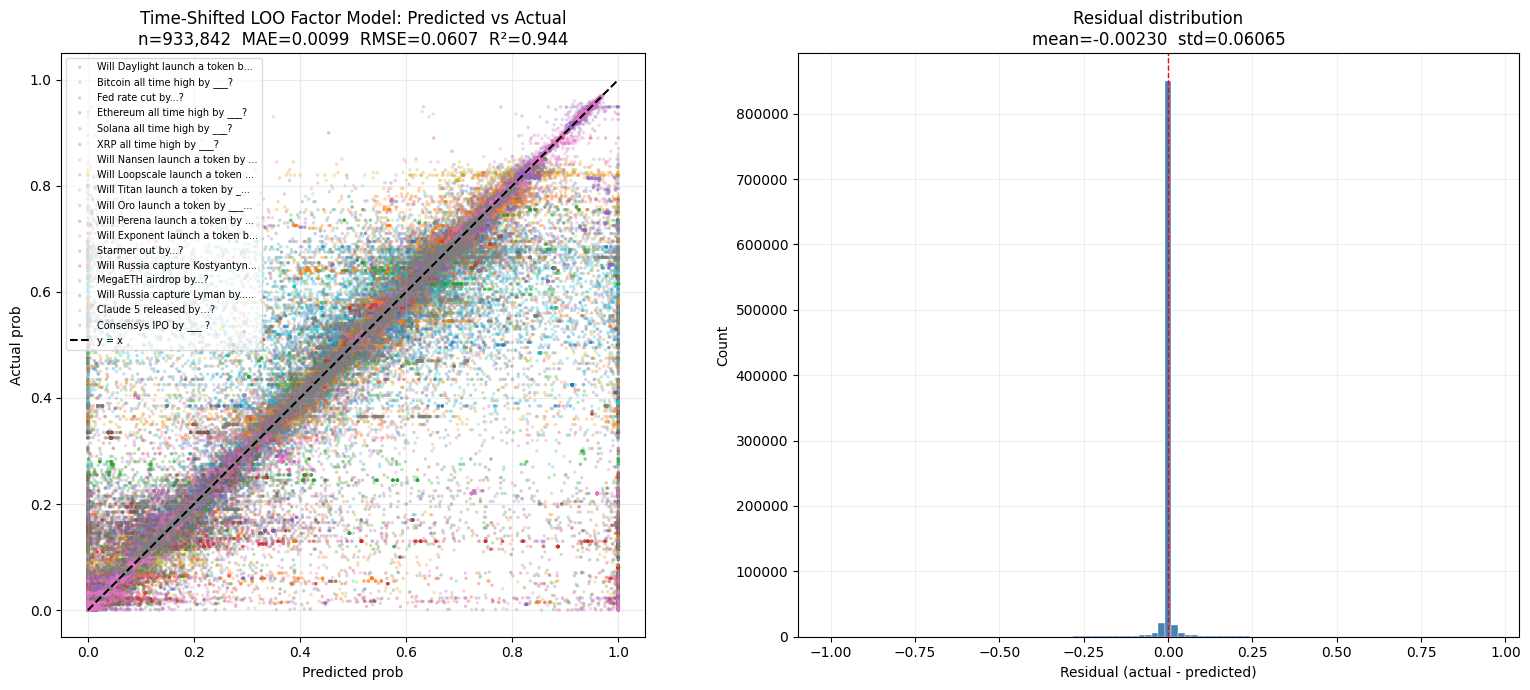

In [41]:
all_events = dyn_df["event_id"].unique()
cmap = plt.colormaps.get_cmap("tab10")
event_colors = {eid: cmap(i % 10) for i, eid in enumerate(all_events)}
event_labels = {
    eid: q[:30] + ("..." if len(q) > 30 else "")
    for eid, q in dyn_df.drop_duplicates("event_id")[["event_id", "question"]].values
}

actual = dyn_df["actual_prob"].to_numpy(dtype=float)
predicted = dyn_df["predicted_prob"].to_numpy(dtype=float)
resid = actual - predicted

mae = np.abs(resid).mean()
rmse = np.sqrt((resid ** 2).mean())
r2 = 1 - resid.var() / actual.var() if actual.var() > 1e-12 else float("nan")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colour-coded scatter
ax = axes[0]
for eid, grp in dyn_df.groupby("event_id"):
    ax.scatter(grp["predicted_prob"], grp["actual_prob"], s=6, alpha=0.3,
               edgecolors="none", color=event_colors[eid], label=event_labels[eid])
lo = min(actual.min(), predicted.min(), 0)
hi = max(actual.max(), predicted.max(), 1)
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="y = x")
ax.set_xlabel("Predicted prob")
ax.set_ylabel("Actual prob")
ax.set_title(f"Time-Shifted LOO Factor Model: Predicted vs Actual\n"
             f"n={len(dyn_df):,}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.3f}")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, loc="upper left", ncol=1, framealpha=0.7)

# Right: residual histogram
ax = axes[1]
ax.hist(resid, bins=100, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Count")
ax.set_title(f"Residual distribution\nmean={resid.mean():.5f}  std={resid.std():.5f}")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## Per-event breakdown


In [42]:
per_event = []
for eid, grp in dyn_df.groupby("event_id"):
    a = grp["actual_prob"].to_numpy(dtype=float)
    p = grp["predicted_prob"].to_numpy(dtype=float)
    r = a - p
    per_event.append({
        "event": event_labels[eid],
        "n_nodes": grp["deadline_date"].nunique(),
        "n_obs": len(grp),
        "MAE": np.abs(r).mean(),
        "RMSE": np.sqrt((r ** 2).mean()),
        "R2": 1 - r.var() / a.var() if a.var() > 1e-12 else float("nan"),
    })

pd.DataFrame(per_event).sort_values("RMSE", ascending=False).reset_index(drop=True)


,event,n_nodes,n_obs,MAE,RMSE,R2
0,Consensys IPO by ___ ?,4,44909,0.022451,0.086479,0.808815
1,Ethereum all time high by ___?,4,59783,0.012410,0.085936,0.114403
2,Will Oro launch a token by ___...,4,51328,0.018719,0.075412,0.807950
3,Solana all time high by ___?,4,34413,0.010837,0.074136,-0.282591
4,Will Nansen launch a token by ...,4,48777,0.011195,0.067201,0.863517
5,Fed rate cut by...?,4,35528,0.013826,0.065694,0.942123
6,Will Exponent launch a token b...,4,53460,0.013768,0.063546,0.933527
7,Will Russia capture Lyman by.....,5,39435,0.007700,0.057503,0.939520
8,MegaETH airdrop by...?,5,76121,0.007825,0.057141,0.971263
9,XRP all time high by ___?,4,65807,0.007364,0.056054,0.427814


## Principal component loadings

For each event, estimate the factor loadings from the most recent lookback window
and plot them against deadline date (tau). Factor 1 ≈ level, Factor 2 ≈ slope.

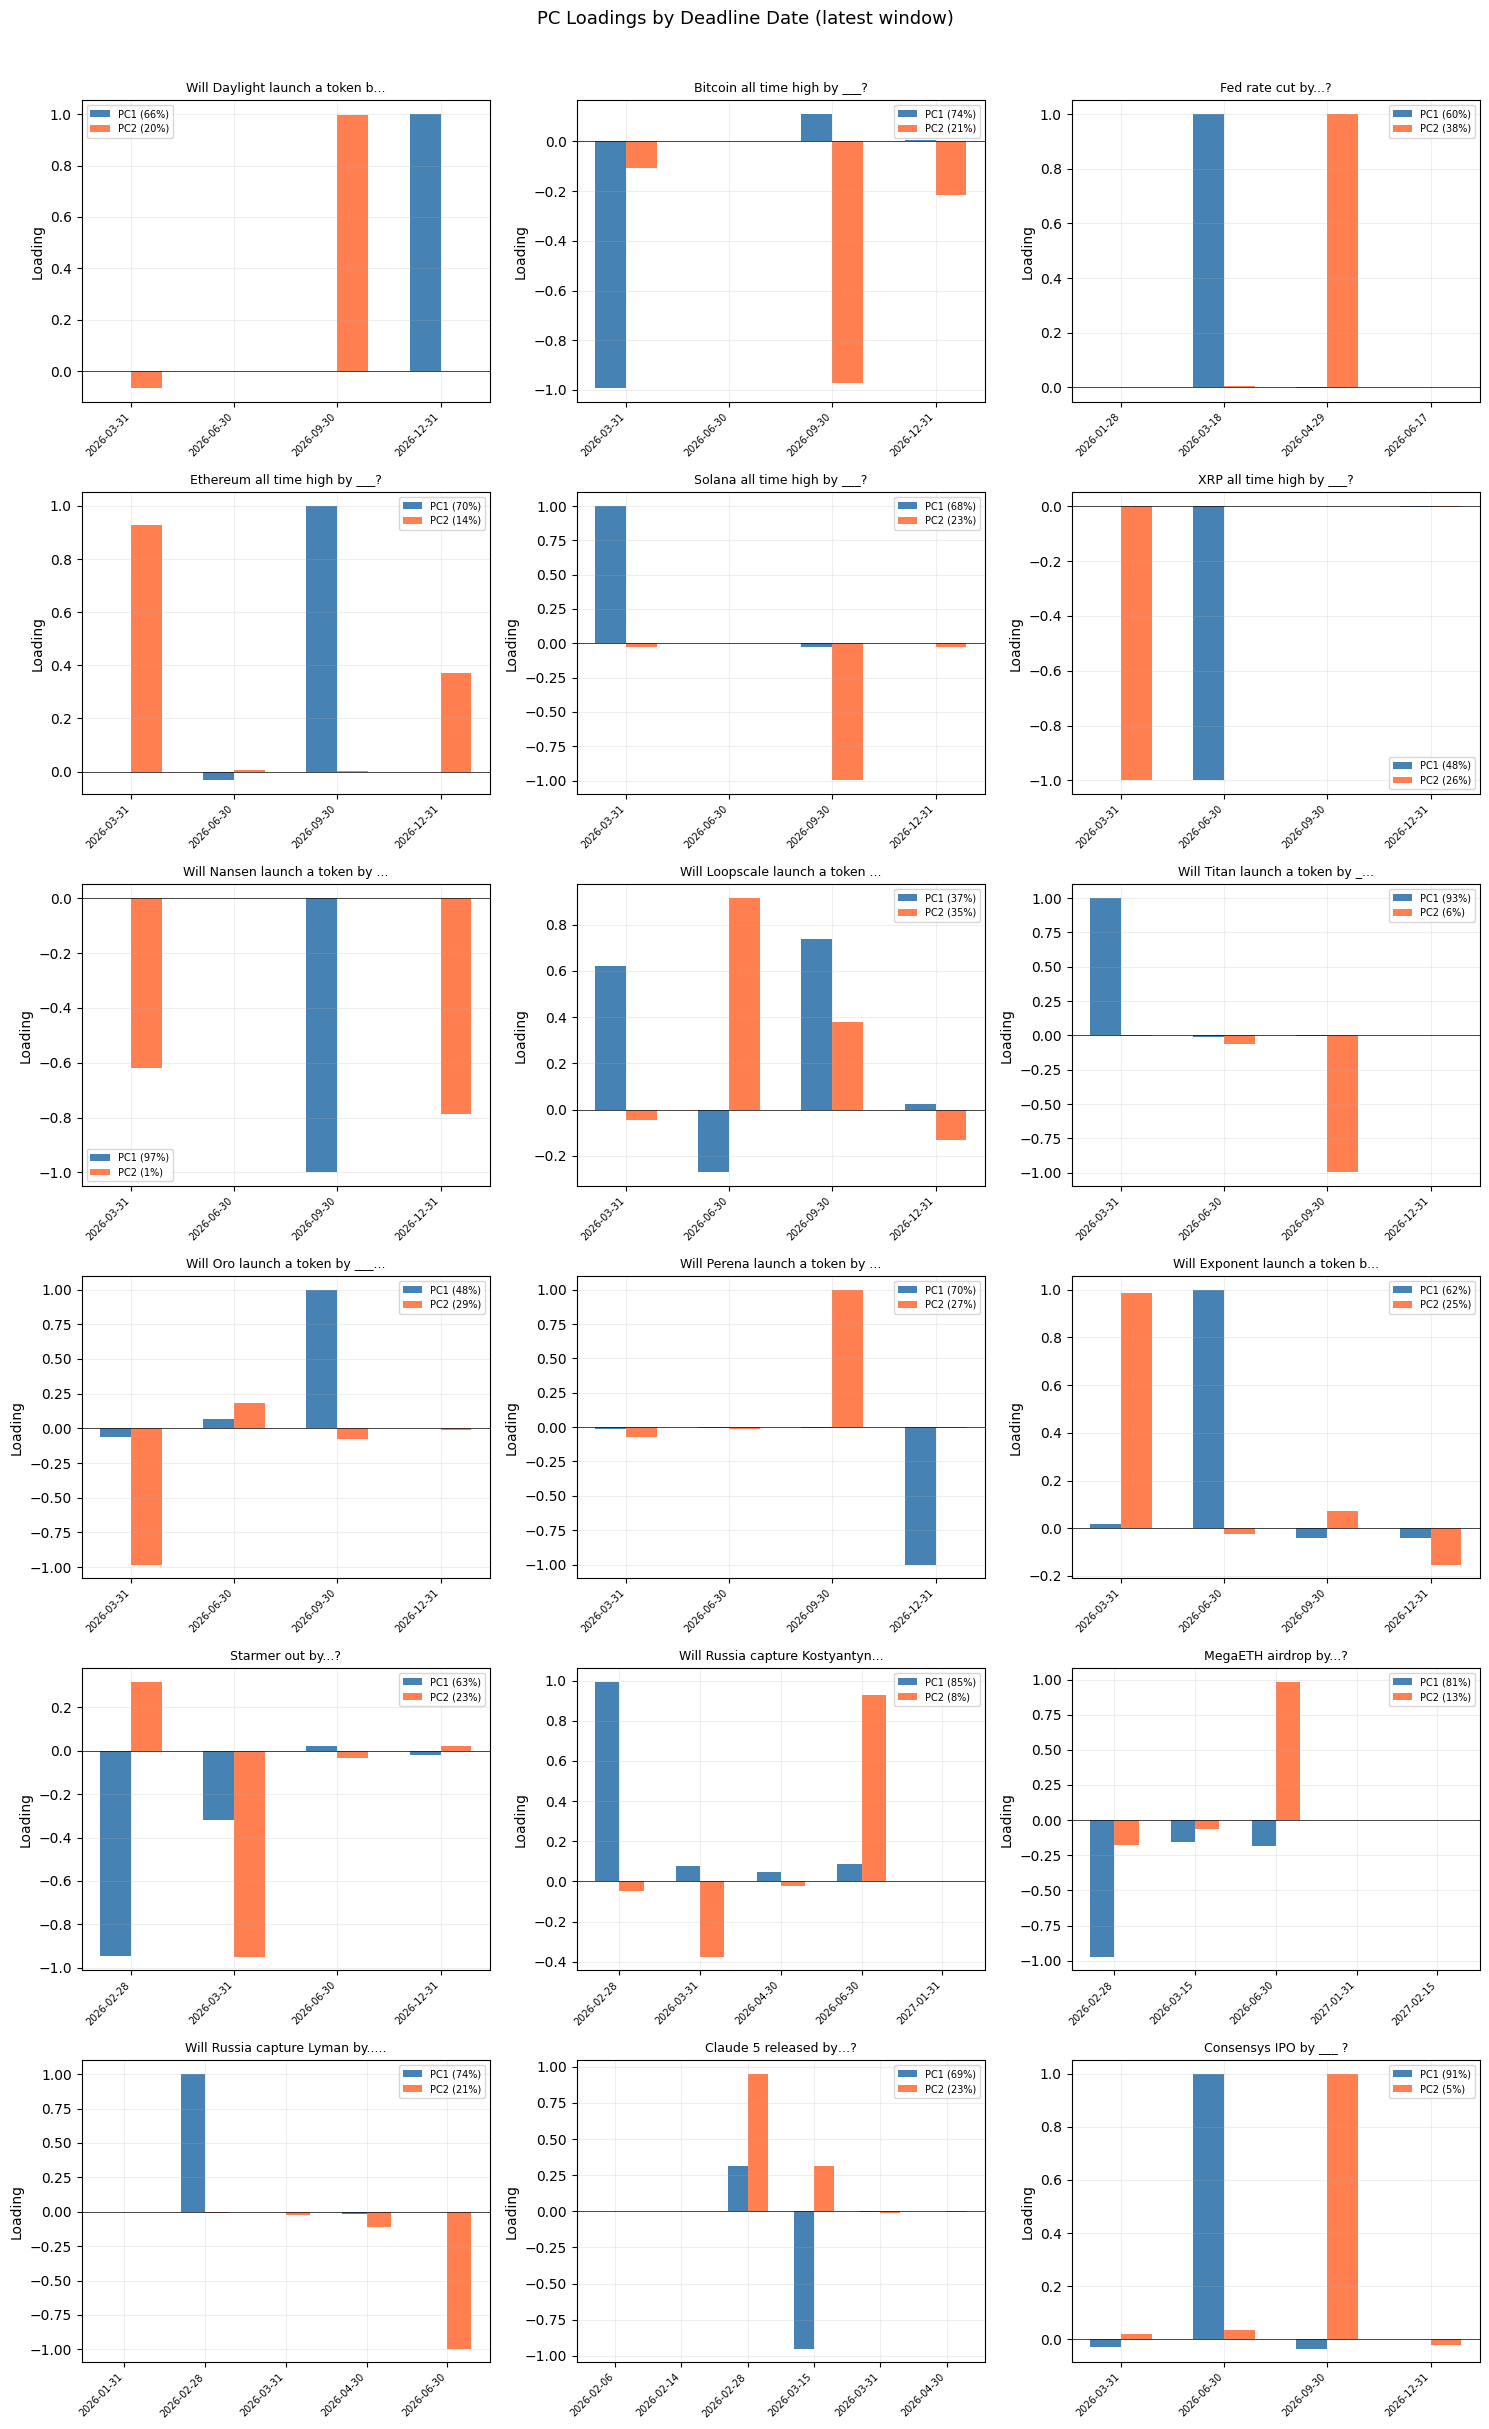

,question,n_nodes,PC1_var,PC2_var,total_var_explained
0,Will Daylight launch a token b...,4,0.658,0.202,0.860
1,Bitcoin all time high by ___?,4,0.737,0.213,0.950
2,Fed rate cut by...?,4,0.602,0.381,0.982
3,Ethereum all time high by ___?,4,0.696,0.137,0.833
4,Solana all time high by ___?,4,0.675,0.226,0.901
5,XRP all time high by ___?,4,0.480,0.261,0.741
6,Will Nansen launch a token by ...,4,0.972,0.015,0.987
7,Will Loopscale launch a token ...,4,0.374,0.350,0.724
8,Will Titan launch a token by _...,4,0.926,0.058,0.984
9,Will Oro launch a token by ___...,4,0.476,0.288,0.763


In [43]:
loadings_data = []

for event_id, edf in panel_df.groupby("event_id", dropna=False):
    question = edf["question"].iloc[0]
    wide = edf.pivot_table(
        index="timestamp", columns="deadline_date",
        values="probability_yes", aggfunc="last",
    )
    wide = wide.sort_index().sort_index(axis=1)
    N = wide.shape[1]
    if wide.shape[0] < LOOKBACK_BARS + 3 or N < max(4, N_FACTORS + 1):
        continue

    wide = wide.interpolate(method="time", limit_direction="both")
    y = pd.DataFrame(_logit(wide.to_numpy()), index=wide.index, columns=wide.columns)
    dy = y.diff().dropna()

    # Use the latest lookback window
    win = dy.iloc[-LOOKBACK_BARS:]
    mu = win.mean(axis=0).to_numpy()
    x = win.to_numpy() - mu
    x = np.nan_to_num(x, nan=0.0)
    u, s, vt = np.linalg.svd(x, full_matrices=False)
    k = min(N_FACTORS, vt.shape[0], vt.shape[1])
    B = vt[:k, :].T  # (N, k)

    # Variance explained
    total_var = (s ** 2).sum()
    var_explained = s[:k] ** 2 / total_var

    for j, dd in enumerate(wide.columns):
        loadings_data.append({
            "event_id": event_id,
            "question": question[:30] + ("..." if len(question) > 30 else ""),
            "deadline_date": dd,
            "PC1_loading": B[j, 0],
            "PC2_loading": B[j, 1] if k > 1 else 0.0,
            "PC1_var_pct": var_explained[0],
            "PC2_var_pct": var_explained[1] if k > 1 else 0.0,
        })

loadings_df = pd.DataFrame(loadings_data)
events_with_loadings = loadings_df["event_id"].unique()
n_events = len(events_with_loadings)

ncols = 3
nrows = (n_events + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)

for idx, eid in enumerate(events_with_loadings):
    ax = axes[idx // ncols, idx % ncols]
    grp = loadings_df[loadings_df["event_id"] == eid].sort_values("deadline_date")
    x_pos = np.arange(len(grp))
    labels = [str(d)[:10] for d in grp["deadline_date"]]

    pc1_var = grp["PC1_var_pct"].iloc[0] * 100
    pc2_var = grp["PC2_var_pct"].iloc[0] * 100

    ax.bar(x_pos - 0.15, grp["PC1_loading"], width=0.3, color="steelblue",
           label=f"PC1 ({pc1_var:.0f}%)")
    ax.bar(x_pos + 0.15, grp["PC2_loading"], width=0.3, color="coral",
           label=f"PC2 ({pc2_var:.0f}%)")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(grp["question"].iloc[0], fontsize=9)
    ax.set_ylabel("Loading")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.2)

# Hide unused axes
for idx in range(n_events, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle("PC Loadings by Deadline Date (latest window)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
summary = (
    loadings_df.groupby(["event_id", "question"])
    .agg(n_nodes=("deadline_date", "nunique"),
         PC1_var=("PC1_var_pct", "first"),
         PC2_var=("PC2_var_pct", "first"))
    .reset_index()
)
summary["total_var_explained"] = summary["PC1_var"] + summary["PC2_var"]
summary[["question", "n_nodes", "PC1_var", "PC2_var", "total_var_explained"]].round(3)

## ACF of LOO factor model residual changes

Autocorrelation of `Δresidual` (first-differenced LOO residuals) per market node.
Comparable to the analytics.ipynb ACF on cross-sectionally demeaned Δresid.

Market nodes with enough data for ACF: 77


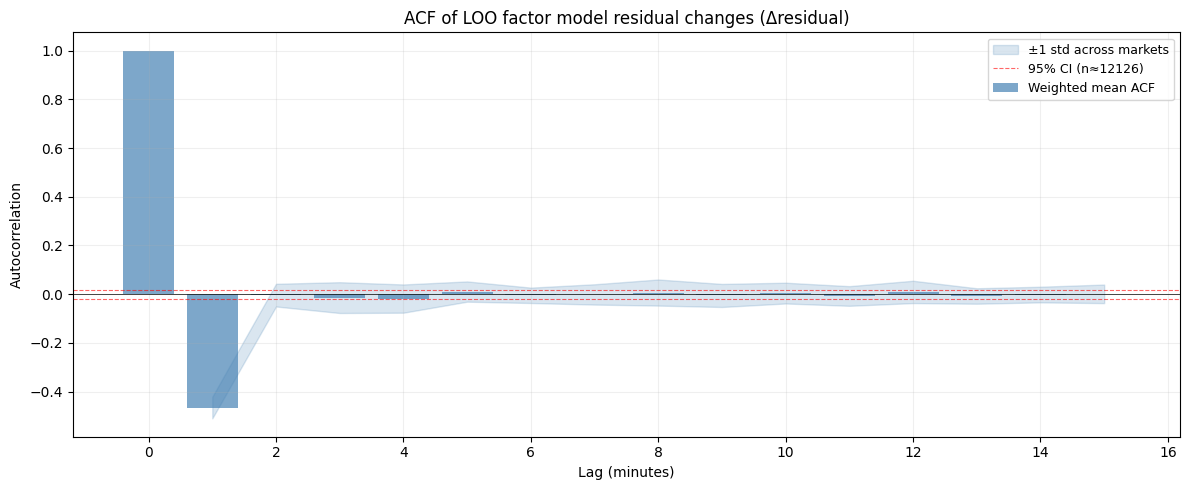

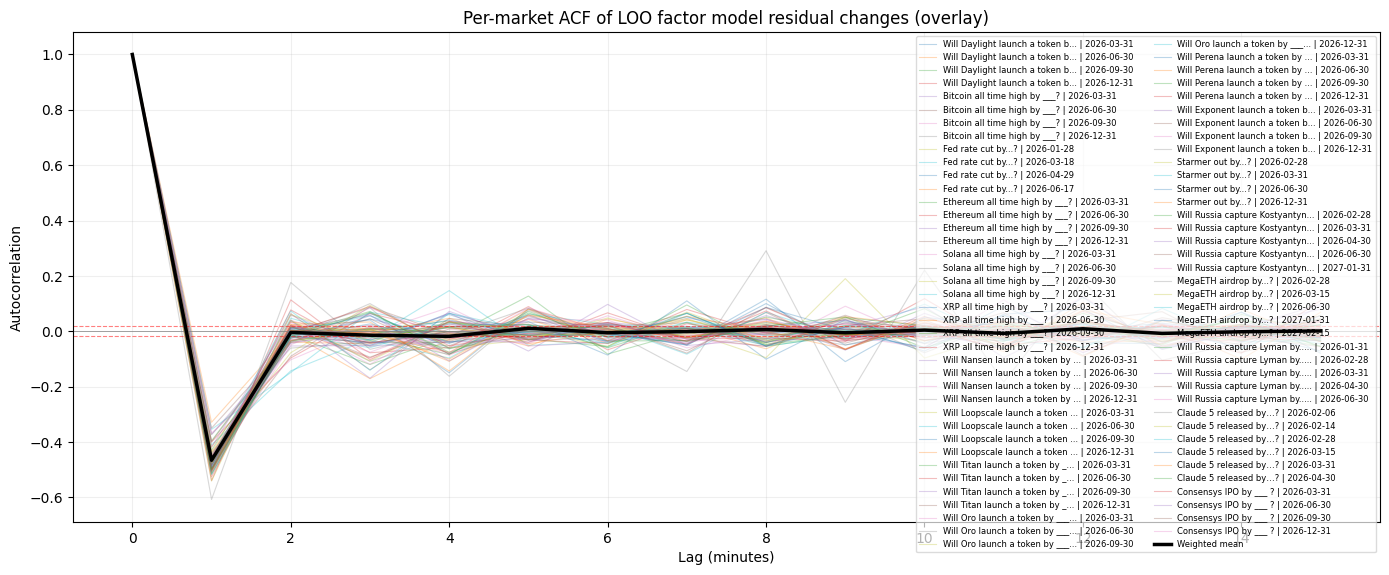

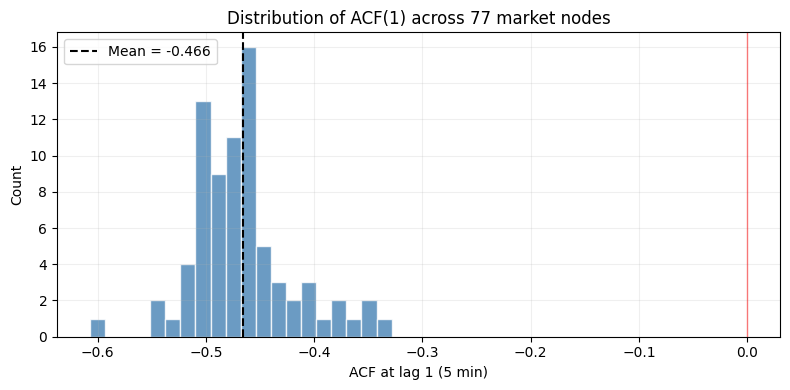


ACF at key lags:
  lag    1m (=1 bars):  -0.4656
  lag    2m (=2 bars):  -0.0039
  lag    3m (=3 bars):  -0.0140
  lag    5m (=5 bars):  0.0108
  lag    7m (=7 bars):  -0.0009
  lag   10m (=10 bars):  0.0045
  lag   15m (=15 bars):  0.0014

ACF(1) summary across 77 nodes:
  Mean:   -0.4662
  Median: -0.4704
  % negative: 100.0%


In [44]:
MAX_ACF_LAG = 15           # 15 bars = 15 minutes at 1-min fidelity
MIN_SERIES_LEN = MAX_ACF_LAG + 10

def _acf(series, max_lag):
    x = series - series.mean()
    var = np.dot(x, x)
    if var < 1e-15:
        return np.full(max_lag, np.nan)
    n = len(x)
    return np.array([np.dot(x[:n-k], x[k:]) / var for k in range(1, max_lag + 1)])

per_market_acfs = []
per_market_weights = []
per_market_labels = []

for (eid, dd), grp in dyn_df.groupby(["event_id", "deadline_date"]):
    resid_series = grp.sort_values("timestamp")["residual"].to_numpy(dtype=float)
    ts = np.diff(resid_series)  # first-difference the residuals
    ts = ts[np.isfinite(ts)]
    if len(ts) < MIN_SERIES_LEN:
        continue
    acf_vals = _acf(ts, MAX_ACF_LAG)
    if np.all(np.isfinite(acf_vals)):
        per_market_acfs.append(acf_vals)
        per_market_weights.append(len(ts))
        short_name = event_labels.get(eid, str(eid))
        per_market_labels.append(f"{short_name} | {dd}")

print(f"Market nodes with enough data for ACF: {len(per_market_acfs)}")

if per_market_acfs:
    acf_matrix = np.array(per_market_acfs)
    weights = np.array(per_market_weights, dtype=float)
    weights /= weights.sum()

    mean_acf = np.average(acf_matrix, axis=0, weights=weights)
    std_acf = np.sqrt(np.average((acf_matrix - mean_acf) ** 2, axis=0, weights=weights))

    lags = np.arange(0, MAX_ACF_LAG + 1)
    lag_minutes = lags * FIDELITY
    mean_acf_full = np.concatenate([[1.0], mean_acf])

    # --- Aggregate ACF plot ---
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(lag_minutes[1:], mean_acf, width=FIDELITY * 0.8, color="steelblue", alpha=0.7,
           label="Weighted mean ACF")
    ax.bar(0, 1.0, width=FIDELITY * 0.8, color="steelblue", alpha=0.7)
    ax.fill_between(lag_minutes[1:], mean_acf - std_acf, mean_acf + std_acf,
                    alpha=0.2, color="steelblue", label="±1 std across markets")

    n_avg = int(np.mean(per_market_weights))
    ci = 1.96 / np.sqrt(n_avg)
    ax.axhline(ci, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label=f"95% CI (n≈{n_avg})")
    ax.axhline(-ci, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_xlabel("Lag (minutes)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title("ACF of LOO factor model residual changes (Δresidual)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # --- Per-market overlay ---
    fig, ax = plt.subplots(figsize=(14, 6))
    for i in range(len(per_market_acfs)):
        acf_with_zero = np.concatenate([[1.0], acf_matrix[i]])
        ax.plot(lag_minutes, acf_with_zero, alpha=0.3, linewidth=0.8,
                label=per_market_labels[i])
    ax.plot(lag_minutes, mean_acf_full, color="black", linewidth=2.5,
            label="Weighted mean", zorder=10)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axhline(ci, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(-ci, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Lag (minutes)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title("Per-market ACF of LOO factor model residual changes (overlay)")
    ax.legend(fontsize=6, loc="upper right", ncol=2, framealpha=0.7)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # --- Histogram of ACF(1) ---
    acf_lag1 = acf_matrix[:, 0]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(acf_lag1, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(np.mean(acf_lag1), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean = {np.mean(acf_lag1):.3f}")
    ax.axvline(0, color="red", linestyle="-", linewidth=1, alpha=0.5)
    ax.set_xlabel("ACF at lag 1 (5 min)")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of ACF(1) across {len(per_market_acfs)} market nodes")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"\nACF at key lags:")
    for k in [1, 2, 3, 5, 7, 10, 15]:
        if k <= MAX_ACF_LAG:
            print(f"  lag {k * FIDELITY:4d}m (={k} bars):  {mean_acf[k-1]:.4f}")

    print(f"\nACF(1) summary across {len(per_market_acfs)} nodes:")
    print(f"  Mean:   {np.mean(acf_lag1):.4f}")
    print(f"  Median: {np.median(acf_lag1):.4f}")
    print(f"  % negative: {(acf_lag1 < 0).mean() * 100:.1f}%")
else:
    print("Not enough market series for ACF analysis.")
